Partie 2 : Votre Premier Projet de Machine Learning de A à Z

 Étape 1 : Exploration et Compréhension des Données (EDA)

In [47]:
#Libraries import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score



sns.set(style="whitegrid")
%matplotlib inline 

# Load the dataset
df = pd.read_csv('train_u6lujuX_CVtuZ9i (1).csv')

# Display first 5 rows to understand structure
print(df.head())

# Check dataset dimensions
print(f"\nDataset shape: {df.shape}")

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Relevant features: Applicant Income + Co Applicant Income / Loan Amount Term / Credit History

In [5]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Observations

Nombre de lignes : 614 / Colonnes : 13

Types de données : cohérents globalement avec variables catégorielles en object, quantitatives en int ou float.

Plusieurs colonnes avec des NaN : 
Gender
Married	
Dependents
Self_Employed
LoanAmount
Loan_Amount_Term
et surtout Credit_History (50 valeurs manquantes), élément clé pour l'octroi de prêts

Types de données cohérents, sauf pour Dependents (object) : contient sans doute la valeur '3+' → à convertir en numérique.


In [63]:
# 2. Traitement de 'Dependents' : remplacement de '3+' par 3 et conversion en float
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

In [64]:
# 3. Imputation des valeurs manquantes
# Catégorielles : remplissage par le mode
for col in ['Gender', 'Married', 'Self_Employed', 'Dependents']:
   df[col] = df[col].fillna(df[col].mode()[0])

In [65]:
# 4. Numériques : remplissage par la médiane
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].median())

In [66]:
# 5. Encodage des variables catégorielles (hors target)
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols)

In [67]:
# 6. Encodage de la variable cible 'Loan_Status'
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [68]:
print(X.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64


In [69]:
# Imputation ciblée pour chaque variable
X['LoanAmount'].fillna(X['LoanAmount'].median())
X['Loan_Amount_Term'].fillna(X['Loan_Amount_Term'].mode()[0])
X['Credit_History'].fillna(X['Credit_History'].mode()[0])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

In [73]:
print(X.columns)
X = df.drop(columns=['Loan_ID', 'Loan_Status'], errors='ignore')
X = X.fillna(X.median(numeric_only=True))  # si pas déjà fait
X = X.astype(int)

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Female', 'Gender_Male',
       'Married_No', 'Married_Yes', 'Education_Graduate',
       'Education_Not Graduate', 'Self_Employed_No', 'Self_Employed_Yes',
       'Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='object')


In [70]:
X = X.astype(int)

ValueError: invalid literal for int() with base 10: 'LP001002'

In [42]:
# 1. On enlève les colonnes inutiles
X = df.drop(columns=['Loan_ID', 'Loan_Status'])

# 2. On transforme les variables catégorielles en variables numériques (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. On convertit tout en int (pour éviter les types bool ou float inutiles)
X = X.astype(int)

# 4. Target variable
y = df['Loan_Status']

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [34]:
print(X.dtypes)

ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Gender_Male                   bool
Married_Yes                   bool
Dependents_1                  bool
Dependents_2                  bool
Dependents_3+                 bool
Education_Not Graduate        bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object


In [20]:
# Vérification finale
print(" Nettoyage terminé !")
print(df.info())
print(df.head())

 Nettoyage terminé !
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               614 non-null    float64
 1   ApplicantIncome          614 non-null    int64  
 2   CoapplicantIncome        614 non-null    float64
 3   LoanAmount               614 non-null    float64
 4   Loan_Amount_Term         614 non-null    float64
 5   Credit_History           614 non-null    float64
 6   Loan_Status              614 non-null    int64  
 7   Gender_Female            614 non-null    bool   
 8   Gender_Male              614 non-null    bool   
 9   Married_No               614 non-null    bool   
 10  Married_Yes              614 non-null    bool   
 11  Education_Graduate       614 non-null    bool   
 12  Education_Not Graduate   614 non-null    bool   
 13  Self_Employed_No         614 non-null    bool   
 14  Self_

1. Histogrammes des variables numériques

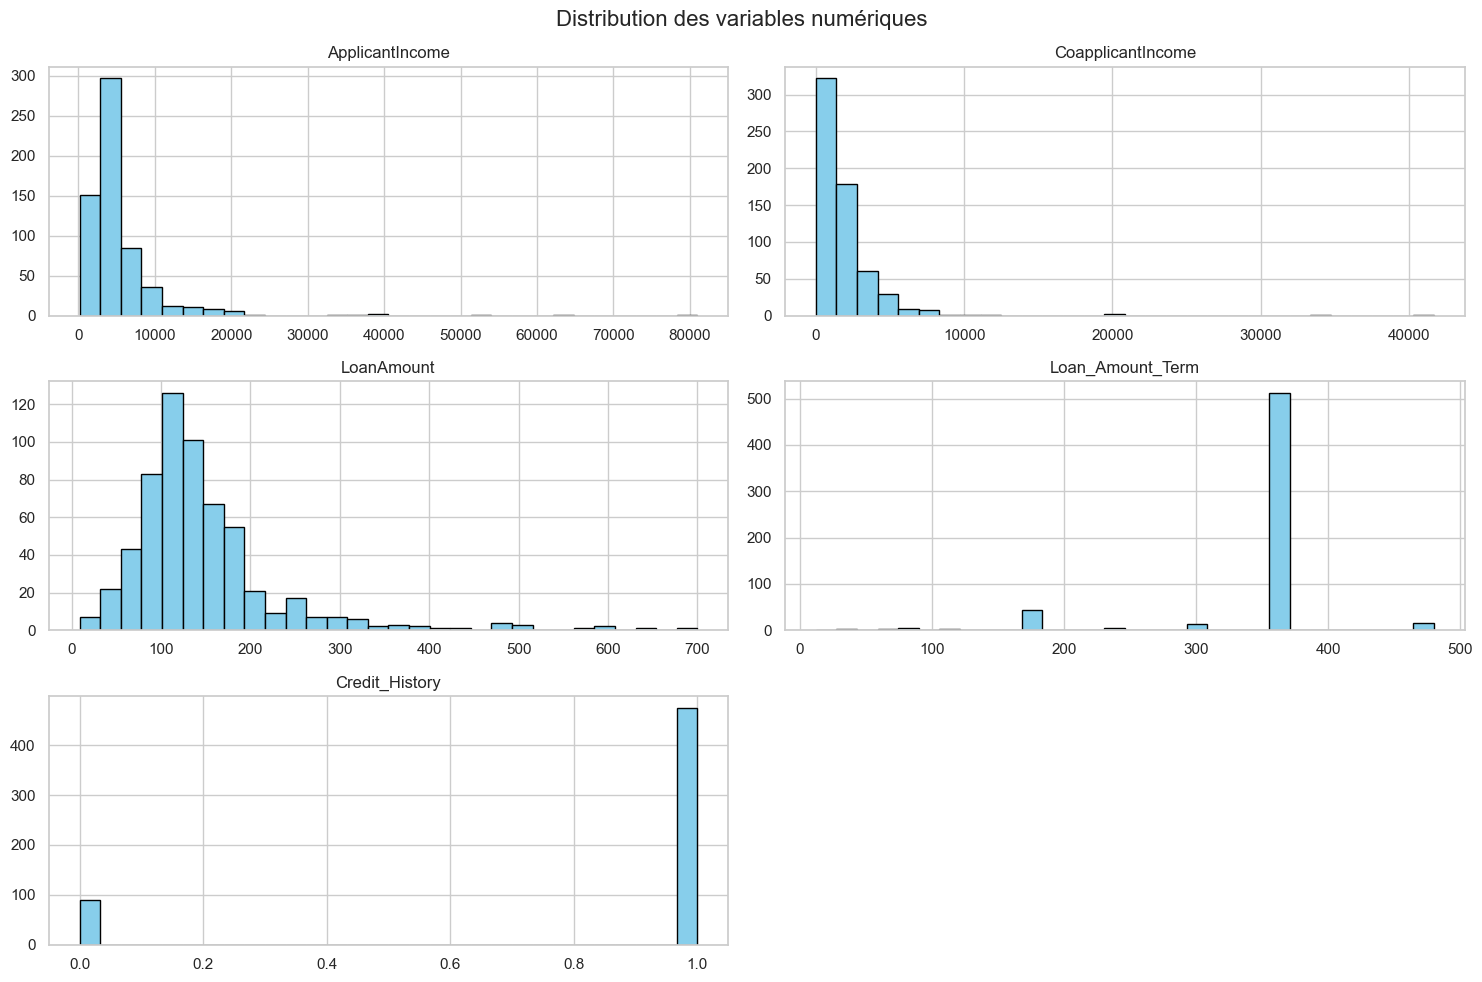

In [23]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

df[numerical_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution des variables numériques', fontsize=16)
plt.tight_layout()
plt.show()

 2. Boxplots pour détecter les outliers

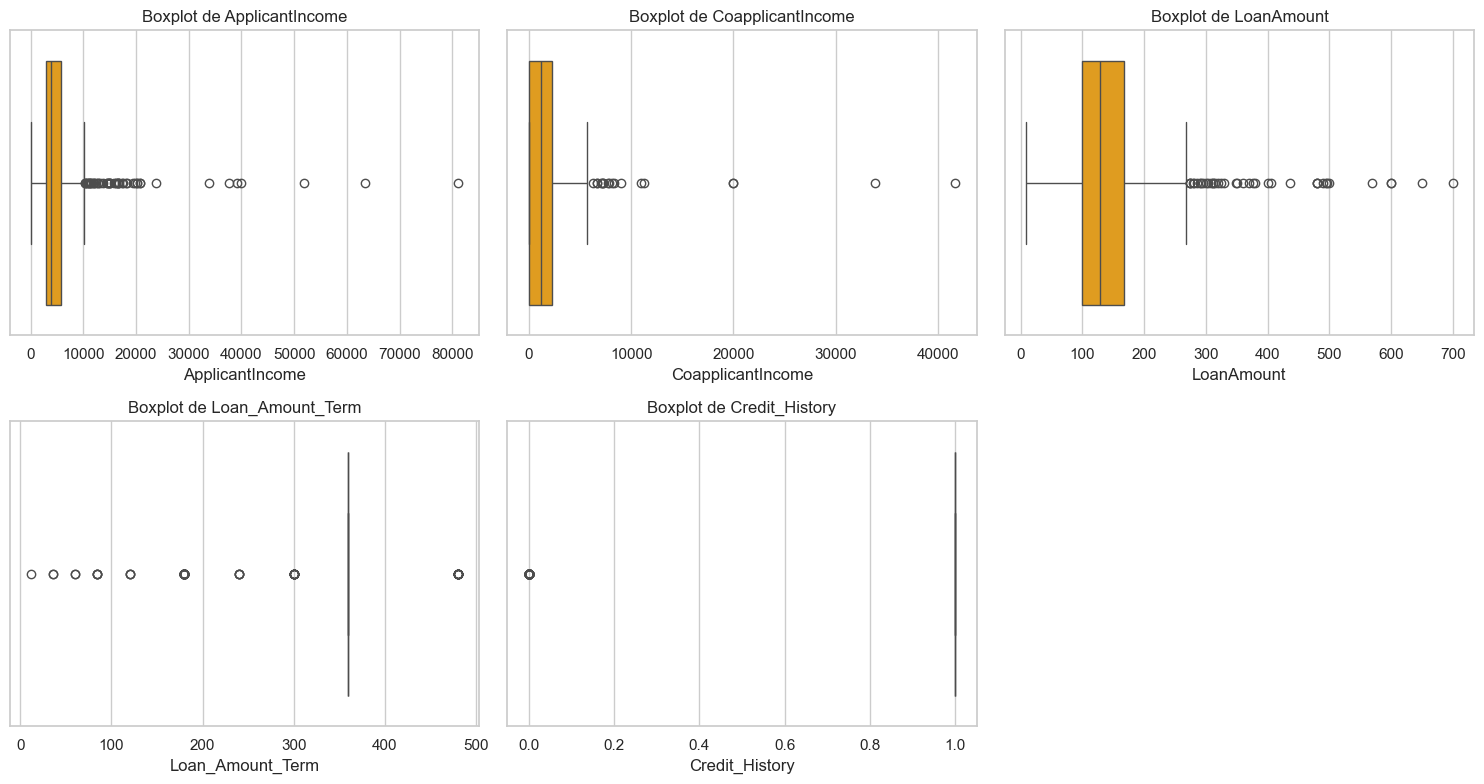

In [43]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

# Observations

ApplicantIncome et LoanAmount ont des outliers très marqués.

Des valeurs > 50k pour les revenus et > 500 pour les montants de prêt.

Les médianes sont bien centrées mais la distribution est asymétrique (skewed à droite).

Loan_Amount_Term : très concentré autour de 360 mois >> valeur dominante.

3. Heatmap des corrélations

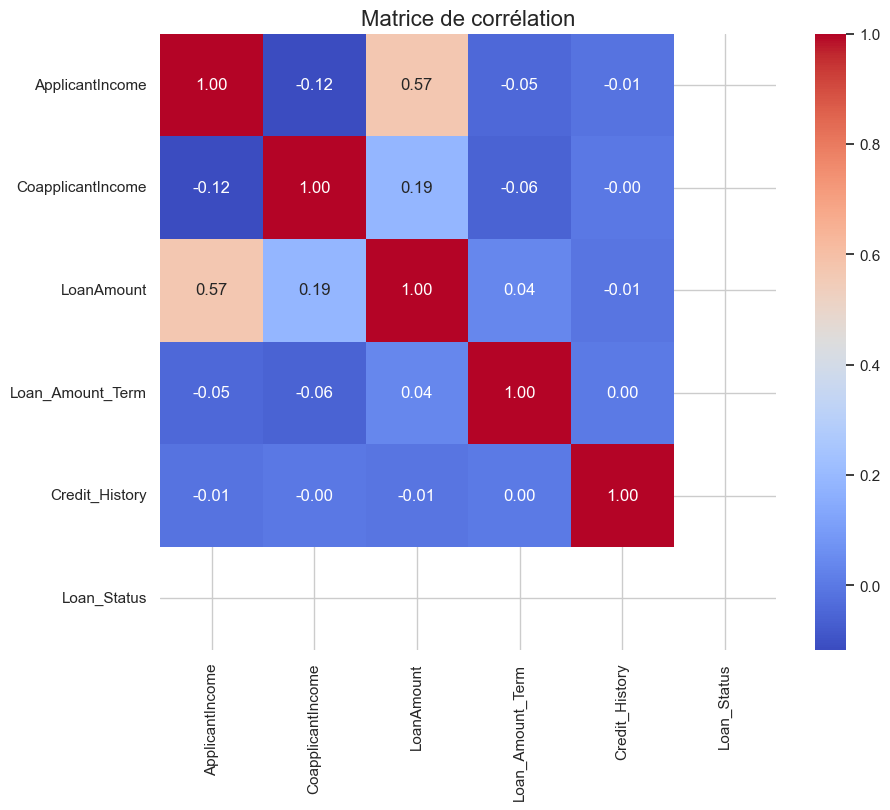

In [44]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation", fontsize=16)
plt.show()

# Observations

ApplicantIncome vs LoanAmount : r = 0.57 >> corrélation modérée, logique : plus le revenu principal est élevé, plus le prêt peut être important. A surveiller

CoapplicantIncome faiblement corrélé à tout >> probablement peu discriminant seul.

Credit_History quasi indépendante des autres variables numériques.

Les autres corrélations sont très faibles voire nulles.


4. Répartition de la variable cible Loan_Status

In [28]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_53935/1918455478.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


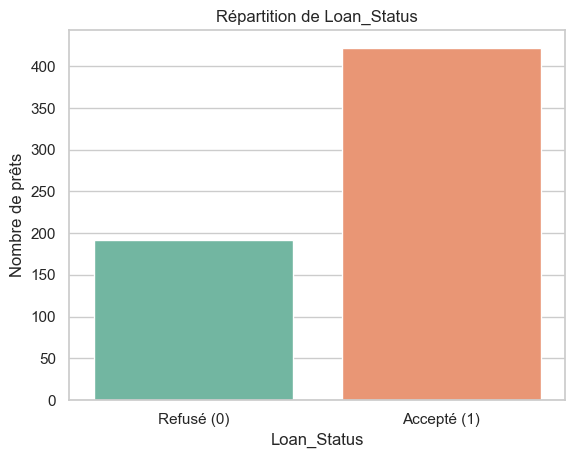

In [29]:
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Répartition de Loan_Status')
plt.xticks([0, 1], ['Refusé (0)', 'Accepté (1)'])
plt.ylabel('Nombre de prêts')
plt.show()

# Observations

69% acceptés vs 32% refusés

5. Influence du revenu vs approbation du prêt

In [46]:
print(df['Loan_Status'].unique())
print(df['Loan_Status'].value_counts())

[nan]
Series([], Name: count, dtype: int64)


ValueError: List of boxplot statistics and `positions` values must have same the length

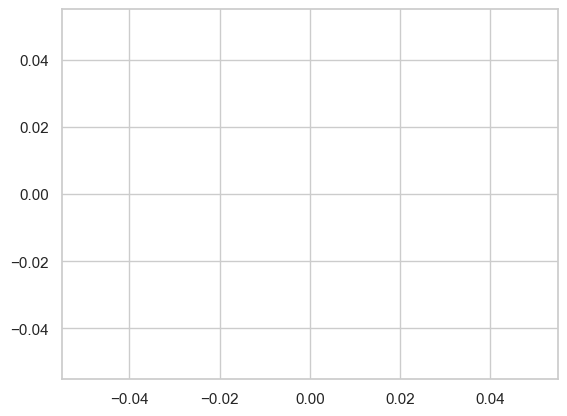

In [74]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Revenu du demandeur selon le statut de prêt")
plt.xticks([0, 1], ['Refusé (0)', 'Accepté (1)'])
plt.show()

# Observations

Les revenus moyens semblent légèrement plus élevés chez les prêts acceptés, mais la variance est énorme (outliers importants) >> le revenu n'est pas le seul critère décisif.

Étape 2 : Préparation des Données et Entraînement des Modèles

1. Sélection des features après EDA

* Conservées car pertinentes :

ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term : variables financières directes

Credit_History : très discriminante

Dependents : information sur charge de famille

Variables catégorielles transformées en dummies : Gender, Married, Education, Self_Employed, Property_Area

* Exclues :

Loan_ID : identifiant >> aucune valeur prédictive

Variables fortement corrélées entre elles

2. Préparation des données

In [76]:
# 4. Nettoyage spécifique
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [77]:
# 5. Supprimer colonnes inutiles
df.drop(columns=['Loan_ID'], inplace=True, errors='ignore')

# 6. Encodage des variables catégorielles
df = pd.get_dummies(df, drop_first=True)

In [78]:
# 7. Séparation features / cible
X = df.drop(columns='Loan_Status')
y = df['Loan_Status']

In [83]:
# Assure-toi que la colonne existe et contient bien des valeurs
print(df['Loan_Status'].unique())

# Supprimer les lignes où Loan_Status est manquant
df = df.dropna(subset=['Loan_Status'])

# Vérifie que les valeurs sont bien 'Y' ou 'N'
print(df['Loan_Status'].value_counts())

# Ensuite, map vers binaire
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Re-vérifie que y est propre
y = df['Loan_Status']
print(y.isnull().sum()) 

[nan]
Series([], Name: count, dtype: int64)
0


In [85]:
df = df.dropna(subset=['Loan_Status'])  # si pas encore fait
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # conversion si pas encore fait

X = df.drop(columns='Loan_Status')
y = df['Loan_Status']

print(y.isnull().sum())  # doit afficher 0

# Ensuite, on peut splitter en toute sécurité :
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

0


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [84]:
# 8. Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

ValueError: Found input variables with inconsistent numbers of samples: [614, 0]

In [49]:
print(df['Loan_Status'].unique())
print(df['Loan_Status'].isnull().sum())
print(df['Loan_Status'].dtype)

['Y' 'N']
0
object


In [50]:
df = df[df['Loan_Status'].notna()]  # supprime les lignes avec NaN dans la cible
df['Loan_Status'] = df['Loan_Status'].astype(int)

ValueError: invalid literal for int() with base 10: 'Y'

In [52]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")

In [53]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [54]:
print(df['Loan_Status'].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [55]:
if df['Loan_Status'].dtype == 'object':
    df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [58]:
df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'].fillna(df['Credit_History'].mode()[0])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

In [59]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [61]:
# 1. Remplir les NaN par la valeur la plus fréquente (mode)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

# 2. Remplacer '3+' par 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

# 3. Convertir en int
df['Dependents'] = df['Dependents'].astype(int)

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_53935/1428184247.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


Je n'ai pas pu bien cleaner ... et donc soucis + chaleur.
:(